# **Short-Term Sales Forecasting Under Volatile Demand**

## Introduction

Accurate short-term sales forecasting is a core capability in modern retail operations. Forecast quality directly impacts inventory availability, working capital efficiency, staffing allocation, and service levels. However, daily retail demand is often spike-driven and highly volatile, shaped by seasonality, calendar effects, evolving trends, and irregular high-impact transactions. Building reliable short-horizon forecasts under these conditions is a meaningful operational challenge.

This project develops a structured, end-to-end short-term demand forecasting framework using approximately four years of historical retail transaction data aggregated into a continuous daily time series. The objective is to generate reliable 7-day ahead forecasts aligned with realistic operational planning cycles in a demand environment characterised by strong seasonality and heavy day-to-day fluctuations. A **7-day horizon was selected to align with weekly replenishment, staffing, and promotional planning cycles, which are both common and operationally important in real-world retail environments**. This window captures a complete weekly seasonality pattern while balancing responsiveness with sufficient forward visibility under volatile demand conditions.

Rather than relying on a single modelling approach, the analysis systematically benchmarks multiple forecasting paradigms within a unified, deployment-aware evaluation framework:

- Naive and seasonal naive baselines  
- ARIMA and SARIMA models  
- Prophet  
- Feature engineered machine learning models including Random Forest and XGBoost  
- A sequence based deep learning model using LSTM  

All models are evaluated using rolling-origin backtesting with a fixed 7-day forecast horizon. This prevents look ahead bias and closely simulates real-world deployment conditions. Performance is assessed using MAE, RMSE, and WMAPE to balance interpretability, sensitivity to volatility, and business relevance.

The objective is not to perfectly predict rare extreme demand spikes, but to identify a model that delivers stable, robust, and operationally defensible short-term forecasts under volatile demand conditions.

> Across aggregated rolling-fold evaluation, gradient boosted tree modelling using **XGBoost delivered the strongest overall performance**, achieving approximately **25 to 31 percent reduction in RMSE relative to naive baselines**. These gains translate into materially improved short-term planning reliability and reduced exposure to large forecast errors during volatile periods.

> In addition to magnitude-based improvements, signed error analysis under rolling-origin evaluation revealed that XGBoost reduced systematic under-forecast bias by approximately **46 to 47 percent** relative to the naive baseline. This improvement strengthens directional calibration in spike-driven demand environments, reducing persistent underestimation during high-activity periods.

> To support transparent model selection, the final model is further analysed using SHAP-based feature importance, combining predictive strength with interpretable insight into the temporal and seasonal drivers of demand.

***This notebook emphasises disciplined validation, structured benchmarking, interpretability, and production-aware thinking, reflecting the principles of real-world demand forecasting systems.***

In [ ]:
# !pip -q install prophet
# !pip -q install xgboost

### Importing Libraries

In [ ]:
# Suppress warning messages
import warnings
warnings.filterwarnings("ignore")

# Core data manipulation libraries
import pandas as pd
import numpy as np

# Data visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Configure visualisation defaults
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

# Utilities for data structures and typing
from dataclasses import dataclass
from typing import Dict, Callable, Tuple, List

# Time series models
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet

# Machine learning models
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from xgboost import XGBRegressor

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

# Deep learning libraries for LSTM
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Model interpretability
import shap

# **Data Ingestion**

In [ ]:
# Load training dataset
df = pd.read_csv("sales_train.csv")

# Preview the first rows of the dataset
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


## **Basic Inspection**

- Inspected the dataset's size, column data types, and non-null counts to understand its structure and completeness.

In [ ]:
# Display dataset dimensions
print("Shape:", df.shape)

# Show column data types and non-null counts
df.info()

Shape: (9800, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   flo

- Checked and ranked missing values across all columns to identify features with the highest levels of missing data.

In [ ]:
# Check for missing values in each column
df.isnull().sum().sort_values(ascending=False)

,0
Postal Code,11
Row ID,0
Order ID,0
Order Date,0
Ship Mode,0
Ship Date,0
Customer Name,0
Segment,0
Country,0
Customer ID,0


## **Preprocessing**

- Converted order and ship dates to datetime format, removed an unnecessary identifier column, and previewed the cleaned dataset to verify the changes.

In [ ]:
# Convert order and ship dates to datetime format
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"]  = pd.to_datetime(df["Ship Date"],  dayfirst=True)

# Remove unnecessary identifier column
df.drop(columns=["Row ID"], inplace=True)

# Preview updated dataset
df.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


- Identified unique city-state combinations associated with missing postal codes to support targeted data cleaning or imputation.

In [ ]:
# Identify cities and states with missing postal codes
print("Missing postal codes (unique City/State):")
df[df["Postal Code"].isnull()][["City", "State"]].drop_duplicates()

Missing postal codes (unique City/State):


,City,State
2234,Burlington,Vermont


- Imputed missing postal codes for Burlington, Vermont using a default ZIP value and verified that no unresolved missing values remained.

In [ ]:
# Define default postal code for Burlington, Vermont
default_burlington_zip = 5401  # Burlington, VT

# Create mask for missing postal codes in Burlington, Vermont
mask = (
    df["Postal Code"].isnull()
    & (df["City"] == "Burlington")
    & (df["State"] == "Vermont")
)

# Impute missing postal codes using the default value
df.loc[mask, "Postal Code"] = default_burlington_zip

# Verify remaining missing values
print("Remaining missing values after ZIP imputation:")
df.isnull().sum().sort_values(ascending=False)

Remaining missing values after ZIP imputation:


,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0
State,0


- Aggregated total sales by order date to create a time-ordered daily sales series for analysis and forecasting.

In [ ]:
# Aggregate total sales by order date
daily_sales = (
    df.groupby("Order Date")["Sales"]
    .sum()
    .reset_index()
    .sort_values("Order Date")
)

# Preview daily sales data
daily_sales.head()

,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


# **Explanatory Data Analysis**

## **Question 1 (a): Is there a discernible trend or recurring pattern in daily sales over time?**

To assess the presence of trend and recurring structure in daily sales, the time series was visualised alongside a 7-day rolling average.

The raw daily sales series captures short-term variability, demand spikes, and noise inherent in retail transactions. However, short-term volatility can obscure broader structural patterns. To address this, a 7-day rolling mean was applied to smooth high-frequency fluctuations and highlight underlying directional movement.

This approach allows us to examine:

- Whether sales exhibit a sustained upward or downward trend over time  
- The presence of weekly seasonality patterns  
- Periods of elevated volatility or structural shifts  
- The persistence and magnitude of demand spikes  

The rolling average provides a clearer view of medium-term dynamics while preserving responsiveness to operationally relevant changes.

**The corresponding visualisation is shown below.**

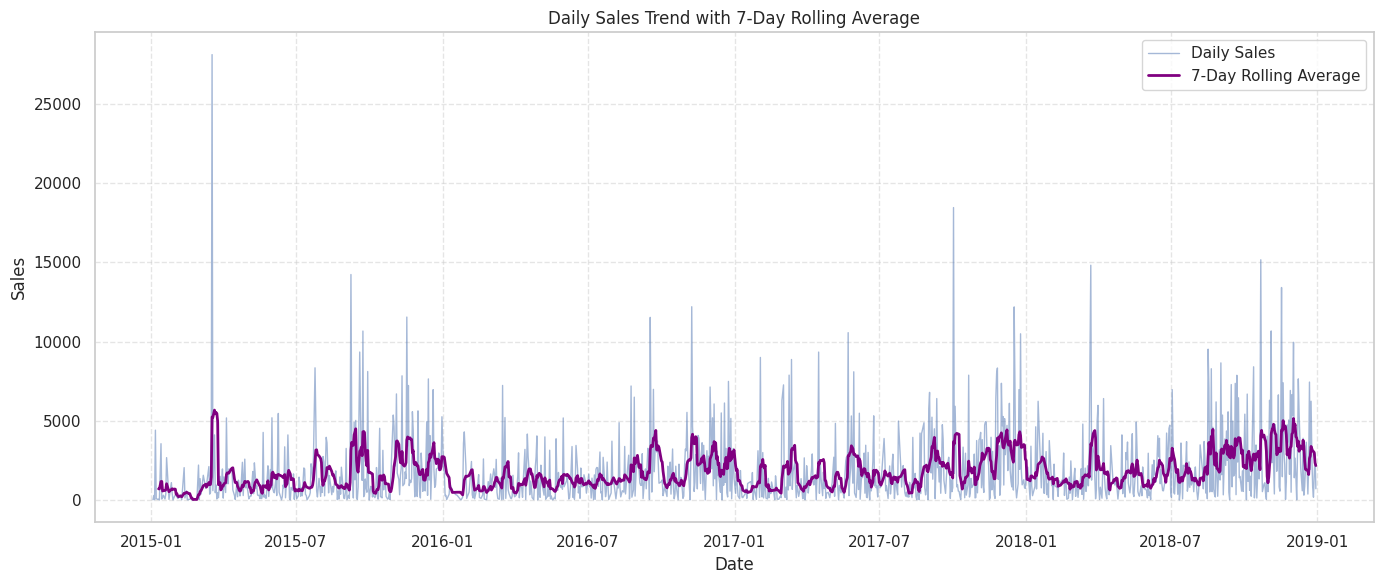

In [ ]:
# Compute 7-day rolling average of daily sales
daily_sales["Rolling Avg (7)"] = daily_sales["Sales"].rolling(window=7).mean()

# Plot daily sales with reduced opacity
plt.plot(
    daily_sales["Order Date"],
    daily_sales["Sales"],
    label="Daily Sales",
    alpha=0.5,
    linewidth=1
)

# Plot rolling average with emphasis
plt.plot(
    daily_sales["Order Date"],
    daily_sales["Rolling Avg (7)"],
    label="7-Day Rolling Average",
    color="purple",
    linewidth=2.0
)

# Configure titles and labels
plt.title("Daily Sales Trend with 7-Day Rolling Average")
plt.xlabel("Date")
plt.ylabel("Sales")

# Improve readability
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

# Adjust layout and display
plt.tight_layout()
plt.show()

## **Observations and Results**

### Overall Trend
The 7-day rolling average indicates a mild but persistent upward trend across the full time horizon. Average daily sales in the later years (2017-2018) are visibly higher than in the earlier period (2015-2016), suggesting gradual demand growth rather than a structural regime shift.

### Temporal Concentration of Sales
Sales activity becomes more frequent and higher in magnitude in the latter half of the dataset. This pattern may reflect business expansion, customer base growth, improved distribution channels, or stronger market penetration over time.

### Seasonality and Recurring Patterns
Recurring spikes appear at regular intervals, particularly toward year-end. This pattern is consistent with seasonal purchasing cycles or holiday-driven demand. Additional mid-year spikes may correspond to promotional campaigns or cyclical budget utilisation patterns.

### Sales Spikes and Outliers
Several pronounced single-day spikes are observed throughout the series. These events do not materially distort the rolling average, indicating that they are isolated rather than sustained shifts in demand. Potential drivers include bulk purchases, B2B transactions, or limited-time promotions. One extreme spike in early 2015 significantly exceeds typical daily levels and warrants separate investigation to determine whether it represents a data anomaly or a genuine business event.

### Volatility and Demand Structure
Daily sales exhibit substantial volatility, characterised by many low-activity days interspersed with occasional high-value transactions. This pattern reflects lumpy demand rather than smooth, continuous consumption, which has direct implications for model selection and evaluation strategy.

---

### Implications for Forecasting

The combination of gradual trend growth, recurring seasonal structure, and pronounced volatility suggests that forecasting models must:

- Capture both trend and calendar-based seasonality  
- Remain robust to extreme values and irregular spikes  
- Be evaluated using scale-aware and business-relevant metrics such as MAE, RMSE, and WMAPE  

Given the irregular demand distribution, model stability and robustness are likely to be more valuable than aggressive short-term spike prediction.

---

### Main Takeaway

> Daily sales are characterised by a gradually increasing baseline, clear seasonal effects, and substantial short-term volatility. Long-term growth is evident, but day-to-day performance is driven by irregular high-impact transactions rather than steady volume. Reliable forecasting will therefore depend more on capturing calendar structure and handling extreme values than on simple short-term trend extrapolation.

---

## **Question 1 (b): Is there a long-term growth trend in total sales at the monthly or yearly level?**

To evaluate long-term growth dynamics, total sales were aggregated at both monthly and yearly levels and visualised using line charts.

- **Monthly aggregation** preserves seasonal structure and intermediate fluctuations, enabling a more granular inspection of recurring patterns and evolving sales momentum.
- **Yearly aggregation** smooths short-term volatility and highlights structural shifts in overall business performance.
- Analysing both resolutions provides a balanced assessment of sustained growth, cyclical behaviour, and structural stability.

This multi-level aggregation approach allows trend identification without being distorted by daily irregularities or isolated transaction spikes.

---

### Note on Weekly Aggregation

Weekly aggregation was explored during the initial exploratory phase but excluded from the final presentation.

While the weekly view confirmed a general upward trajectory in sales, it exhibited higher event-driven volatility and lacked stable, calendar-aligned interpretability relative to the monthly analysis. Given the four-year daily dataset, monthly and yearly aggregations were sufficient to capture both seasonal structure and long-term growth dynamics.

To maintain analytical clarity and avoid redundancy, weekly aggregation was omitted from the final narrative. The corresponding code remains available in a commented state for transparency and reproducibility.

In [ ]:
# # Convert order date to datetime
# df["Order Date"] = pd.to_datetime(df["Order Date"])

# # Aggregate total sales by week (Monday as week start)
# weekly = (
#     df.assign(Week=df["Order Date"].dt.to_period("W-MON").dt.start_time)
#       .groupby("Week")["Sales"]
#       .sum()
#       .reset_index()
#       .sort_values("Week")
# )

# # Compute 2-week moving average
# weekly["MA_2W"] = weekly["Sales"].rolling(2).mean()

# fig = go.Figure()

# # Plot weekly sales
# fig.add_trace(
#     go.Scatter(
#         x=weekly["Week"],
#         y=weekly["Sales"],
#         mode="lines+markers",
#         name="Weekly Sales",
#         customdata=weekly["Week"].dt.strftime("Week of %d %b %Y"),
#         hovertemplate="<b>%{customdata}</b><br>Sales: %{y:,.2f}<extra></extra>"
#     )
# )

# # Plot 2-week moving average
# fig.add_trace(
#     go.Scatter(
#         x=weekly["Week"],
#         y=weekly["MA_2W"],
#         mode="lines",
#         name="2-Week Moving Avg",
#         hovertemplate="<b>%{x|%d %b %Y}</b><br>2W Avg: %{y:,.2f}<extra></extra>"
#     )
# )

# # Configure layout
# fig.update_layout(
#     title="Weekly Sales Trend",
#     xaxis_title="Week",
#     yaxis_title="Sales",
#     template="plotly_white",
#     hovermode="x unified"
# )

# fig.show()

In [ ]:
# Aggregate total sales by month
monthly_sales = (
    df.assign(Month=df["Order Date"].dt.to_period("M").dt.to_timestamp())
      .groupby("Month")["Sales"]
      .sum()
      .reset_index()
      .sort_values("Month")
)

# Aggregate total sales by year
yearly_sales = (
    df.assign(Year=df["Order Date"].dt.year)
      .groupby("Year")["Sales"]
      .sum()
      .reset_index()
      .sort_values("Year")
)

# Create 1 row, 2 columns layout
fig = make_subplots(
    rows=1,
    cols=2,
    column_widths=[0.95, 0.05],
    subplot_titles=("Monthly Sales Trend", "Yearly Sales Trend")
)

# Monthly sales chart
fig.add_trace(
    go.Scatter(
        x=monthly_sales["Month"],
        y=monthly_sales["Sales"],
        mode="lines+markers+text",
        text=monthly_sales["Month"].dt.strftime("%b %Y"),
        textposition="top center",
        line=dict(color="black", width=3),
        marker=dict(size=6, color="red")
    ),
    row=1, col=1
)

# Yearly sales chart
fig.add_trace(
    go.Scatter(
        x=yearly_sales["Year"],
        y=yearly_sales["Sales"],
        mode="lines+markers",
        line=dict(color="black", width=3),
        marker=dict(size=8, color="red")
    ),
    row=1, col=2
)

# Axis formatting
fig.update_xaxes(
    title_text="Month",
    tickformat="%b %Y",
    dtick="M6",
    row=1, col=1
)

fig.update_xaxes(
    title_text="Year",
    tickmode="linear",
    dtick=1,
    row=1, col=2
)

fig.update_yaxes(title_text="Total Sales", row=1, col=1)
fig.update_yaxes(title_text="Total Sales", row=1, col=2)

# Layout styling
fig.update_layout(
    title="Sales Trends: Monthly vs Yearly",
    hovermode="x unified",
    template="plotly_white",
    showlegend=False
)

fig.show()

## **Observations and Results**

### Trend, Seasonality, and Intra-Year Dynamics (Monthly Perspective)

Monthly sales display pronounced seasonality layered on top of a clear upward trend.

- Sales consistently **decline** in the early part of the year (January-February) and **peak** in the final quarter (September-December).
- Beyond broad seasonality, recurring intra-year transition patterns are visible across multiple years. Sales frequently increase from **February to March**, accelerate from **August to September**, soften from **September to October**, and rebound from **October to November**.

Although not perfectly uniform, the repeated direction and timing of these movements indicate structured monthly dynamics rather than random variation.

---

### Long-Term Growth Dynamics (Yearly Perspective)

Annual aggregation confirms a **clear upward trajectory** across the observed period. A mild contraction in the early years is short-lived and followed by sustained and accelerating growth toward the end of the dataset. This pattern supports the presence of durable long-term expansion.

---

### Shift in Growth Regime

A structural shift becomes evident after 2016 and is observable at both monthly and yearly levels.

- At the **monthly level**, late-year peaks become progressively higher and more pronounced.
- At the **yearly level**, total sales increase at an accelerating rate.

The consistency of this shift across aggregation levels suggests a genuine change in underlying business dynamics rather than an artefact of temporal aggregation.

---

### Momentum and Persistence

Growth appears persistent rather than episodic. Monthly gains occur in sustained sequences rather than isolated spikes, while consecutive year-on-year increases reinforce the presence of durable momentum.

---

### Aggregation Effects and Signal Robustness

Monthly aggregation preserves seasonal structure and transitional dynamics, while yearly aggregation smooths short-term noise and highlights structural change. The alignment of signals across both resolutions strengthens confidence that observed patterns reflect genuine performance behaviour.

---

### Implications for Forecasting

Forecasting models should incorporate:

- A positive long-term trend component  
- Explicit seasonal structure  
- Month-specific or calendar-driven effects  

Ignoring intra-year dynamics would risk systematically underestimating demand during predictable surge periods.

---

### Main Takeaway

> Monthly analysis reveals strong seasonality and recurring intra-year transition patterns, particularly post-winter rebounds and late-year surges. Yearly aggregation confirms sustained and strengthening growth after 2016. Together, these findings support the use of trend-aware and seasonality-aware forecasting models.

---

## **Question 2: Are there significant differences in total sales performance across regions?**

To evaluate geographic performance disparities, total sales were aggregated by region and visualised using a horizontal bar chart.

Regional aggregation enables a clear comparison of revenue contribution across geographic segments, helping to identify concentration risk, growth opportunities, and potential imbalances in market penetration.

The horizontal bar chart facilitates:

- Direct comparison of absolute sales contribution  
- Identification of leading and underperforming regions  
- Assessment of sales concentration across the geographic portfolio  

This analysis provides an initial view of whether performance is evenly distributed or disproportionately driven by specific regions, with implications for resource allocation, expansion strategy, and demand forecasting granularity.

In [ ]:
# Aggregate total sales by region
region_sales = (
    df.groupby("Region")["Sales"]
    .sum()
    .reset_index()
    .sort_values("Sales", ascending=True)
)

# Create horizontal bar chart with a single neutral color
fig = px.bar(
    region_sales,
    x="Sales",
    y="Region",
    orientation="h",
    title="Total Sales by Region",
    labels={"Sales": "Total Sales", "Region": "Region"}
)

# Apply uniform dark gray styling
fig.update_traces(marker_color="#2c3e50")

# Improve layout and readability
fig.update_layout(
    hovermode="x unified",
    template="plotly_white",
    showlegend=False
)

fig.show()

## **Observations and Results**

### Regional Sales Distribution

Total sales are unevenly distributed across regions, indicating that geographic factors materially influence overall performance. Revenue generation is concentrated in a subset of regions rather than evenly dispersed across the portfolio.

---

### Leading Regions

The **West** region records the highest total sales, followed closely by the **East**. The relatively narrow gap between these two regions suggests that both represent mature, high-performing markets with strong and sustained demand foundations.

---

### Mid-Tier Performance

The **Central** region demonstrates moderate sales performance. While materially below the leading regions, it performs significantly above the lowest-ranked region. This positioning may reflect partial market penetration, heterogeneous customer density, or variation in regional purchasing behaviour.

---

### Lagging Region

The **South** region contributes the lowest total sales. The performance gap relative to the leading regions is substantial, suggesting potential structural constraints such as lower demand concentration, fewer high-value customers, or distribution limitations.

---

### Sales Concentration

A significant proportion of total revenue is generated by the West and East combined. This concentration implies a degree of geographic dependency, where overall performance is disproportionately influenced by a limited number of regional markets.

---

### Implications for Forecasting and Strategy

Regional heterogeneity should be explicitly incorporated into forecasting and planning frameworks. Potential approaches include:

- Region-specific modelling or segmentation  
- Inclusion of geographic features within machine learning models  
- Differential resource allocation based on regional growth dynamics  

From a strategic perspective, sustaining momentum in high-performing regions while diagnosing growth barriers in underperforming markets may improve long-term resilience and revenue diversification.

---

### Main Takeaway

> Sales performance is geographically concentrated, with a limited number of regions driving a disproportionate share of total revenue. Geographic effects are therefore structurally significant rather than purely descriptive, making regional segmentation essential for both robust forecasting and informed strategic decision-making.

---

## **Question 3: Do sales performance levels differ significantly across product categories?**

To evaluate performance differences across product segments, total sales were aggregated by product category and visualised using a bar chart.

Category-level aggregation enables a clear assessment of revenue contribution across the product portfolio, helping to identify dominant segments, diversification patterns, and potential concentration risk.

The bar chart supports:

- Direct comparison of absolute sales contribution by category  
- Identification of high-performing and underperforming segments  
- Assessment of portfolio balance and revenue dependency  

This analysis provides an initial view of whether overall performance is broadly distributed across categories or disproportionately driven by a small number of product segments, with implications for inventory planning, forecasting granularity, and strategic product focus.

In [ ]:
# Aggregate total sales by product category
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .reset_index()
    .sort_values("Sales", ascending=False)
)

# Create bar chart with a single neutral color
fig = px.bar(
    category_sales,
    x="Category",
    y="Sales",
    title="Total Sales by Category",
    labels={"Sales": "Total Sales", "Category": "Category"}
)

# Apply uniform dark gray styling
fig.update_traces(marker_color="#2c3e50")

# Improve layout and readability
fig.update_layout(
    template="plotly_white",
    showlegend=False
)

fig.show()

## **Observations and Results**

### Category-Level Sales Structure

Total sales are distributed across product categories with noticeable but not extreme variation. Revenue appears diversified rather than concentrated in a single dominant segment.

---

### Leading Category

**Technology** records the highest total sales among all categories. This may reflect higher average transaction values, recurring upgrade cycles, or broader cross-segment applicability.

---

### Comparable Mid-Tier Categories

**Furniture** and **Office Supplies** follow closely behind Technology, with relatively modest differences in total sales. Their comparable performance indicates that these categories are core contributors to overall revenue rather than secondary product lines.

---

### Revenue Balance and Portfolio Diversification

The absence of a disproportionately dominant category suggests a balanced product portfolio. This diversification reduces revenue concentration risk and implies that overall growth is supported by multiple product segments.

---

### Demand Stability

The relatively narrow spread between category totals indicates stable category-level demand structures. While sub-category volatility may exist, performance at the aggregate category level appears structurally consistent.

---

### Implications for Forecasting

Category should be incorporated as a meaningful explanatory feature within forecasting models, but not treated as the sole primary driver. Potential approaches include:

- Including category-level features in machine learning models  
- Applying hierarchical or segmented forecasting frameworks  
- Modelling interaction effects between category and seasonality  

Given the balanced contribution structure, category effects are likely to enhance predictive stability rather than dominate model behaviour.

---

### Main Takeaway

> Sales are supported by a well-balanced category mix, with no single product segment disproportionately driving revenue. This diversification strengthens overall revenue resilience and suggests that category-level effects should be modelled as structured contributors rather than dominant determinants of performance.

---

## **Question 4: Is sales performance unevenly distributed across product sub-categories?**

To assess revenue concentration at a finer level of detail, total sales were aggregated by product sub-category and visualised using a horizontal bar chart.

Sub-category aggregation enables a granular evaluation of performance within broader product categories, helping to identify internal revenue concentration, niche high-performing segments, and potential underperforming lines.

The horizontal bar chart facilitates:

- Direct comparison of absolute sales contribution across sub-categories  
- Identification of disproportionately strong or weak segments  
- Assessment of intra-category revenue dispersion  

This analysis helps determine whether revenue diversification at the category level persists at a more granular resolution, or whether performance is driven by a limited number of high-impact sub-categories with implications for inventory planning, portfolio optimisation, and forecasting segmentation.

In [ ]:
# Aggregate total sales by sub-category
subcat_sales = (
    df.groupby("Sub-Category")["Sales"]
    .sum()
    .reset_index()
    .sort_values("Sales", ascending=True)
)

# Create horizontal bar chart with a single neutral color
fig = px.bar(
    subcat_sales,
    x="Sales",
    y="Sub-Category",
    orientation="h",
    title="Total Sales by Sub-Category",
    labels={"Sales": "Total Sales", "Sub-Category": "Sub-Category"}
)

# Apply uniform dark gray styling
fig.update_traces(marker_color="#2c3e50")

# Improve layout and readability
fig.update_layout(
    hovermode="y unified",
    template="plotly_white",
    showlegend=False
)

fig.show()

## **Observations and Results**

### Sub-Category Sales Structure

Sales are markedly uneven across sub-categories, indicating that revenue is concentrated in a limited number of product lines rather than evenly distributed across the portfolio.

---

### Dominant Sub-Categories

**Phones** and **Chairs** are the leading contributors, generating substantially higher total sales than all other sub-categories. Their outsized contribution suggests that these products are central drivers of overall revenue performance.

---

### Upper-Mid Tier Performance

**Storage**, **Tables**, **Binders**, and **Machines** form a secondary performance tier. While these sub-categories contribute meaningfully to total sales, their impact remains materially below that of the leading products.

---

### Lower-Tier Contributors

Sub-categories such as **Labels**, **Envelopes**, **Art**, and **Fasteners** generate comparatively low total sales. Although they expand product breadth, their contribution to aggregate revenue is limited.

---

### Long-Tail Distribution

The distribution exhibits a clear long-tail structure: a small number of sub-categories account for a disproportionate share of revenue, while the majority contribute marginally. This pattern highlights structural concentration at the granular product level.

---

### Implications for Forecasting and Strategy

Sub-category heterogeneity should be explicitly incorporated into forecasting and operational planning. Potential approaches include:

- Hierarchical or segmented forecasting models  
- Separate modelling of dominant sub-categories  
- Inventory and promotional prioritisation aligned with revenue concentration  

Given the long-tail structure, aggregate category-level analysis may obscure substantial underlying variation, reducing forecast precision if sub-category effects are ignored.

---

### Main Takeaway

> Sales are heavily concentrated at the sub-category level, with a small number of products driving a disproportionate share of total revenue. Fine-grained product segmentation is therefore essential for accurate forecasting and informed operational decision-making, as higher-level aggregation masks meaningful structural variation.

---

## **Question 5: Do total sales differ significantly across customer segments?**

To evaluate variation in revenue across customer types, total sales were aggregated by customer segment and visualised using a bar chart.

Segment-level aggregation enables a structured comparison of revenue contribution across distinct customer groups, helping to identify concentration patterns, demand intensity differences, and potential segmentation effects.

The bar chart supports:

- Direct comparison of absolute sales contribution by segment  
- Identification of dominant and underperforming customer groups  
- Assessment of revenue diversification across the customer base  

This analysis helps determine whether overall performance is broadly distributed across segments or disproportionately driven by specific customer groups, with implications for segmentation strategy, targeted forecasting, and resource allocation.

In [ ]:
# Aggregate total sales by customer segment
segment_sales = (
    df.groupby("Segment")["Sales"]
    .sum()
    .reset_index()
    .sort_values("Sales", ascending=False)
)

# Create bar chart with a single neutral color
fig = px.bar(
    segment_sales,
    x="Segment",
    y="Sales",
    title="Total Sales by Customer Segment",
    labels={"Sales": "Total Sales", "Segment": "Segment"}
)

# Apply uniform dark gray styling
fig.update_traces(marker_color="#2c3e50")

# Improve layout and readability
fig.update_layout(
    template="plotly_white",
    showlegend=False
)

fig.show()

## **Observations and Results**

### Customer Segment Contribution

Total sales are unevenly distributed across customer segments, indicating material differences in purchasing behaviour and revenue contribution.

---

### Dominant Segment

The **Consumer** segment accounts for the largest share of total sales, contributing a substantial proportion of overall revenue. This suggests that individual or small-scale purchases collectively form the primary revenue engine of the business.

---

### Secondary Segment

The **Corporate** segment represents a meaningful but clearly smaller share of total sales. While corporate customers contribute materially to overall performance, their aggregate impact remains well below that of the Consumer segment.

---

### Lower-Impact Segment

The **Home Office** segment generates the lowest total sales. Its comparatively modest contribution may reflect a smaller customer base, lower transaction values, or less frequent purchasing patterns.

---

### Revenue Concentration

A significant proportion of total revenue is concentrated within the Consumer segment, indicating structural reliance on this customer group for sustained performance.

---

### Implications for Forecasting and Strategy

Customer segment should be incorporated as a key explanatory variable within forecasting models. Potential enhancements include:

- Segment-level feature inclusion in machine learning models  
- Segmented or hierarchical forecasting approaches  
- Differential demand modelling by customer type  

From a strategic perspective, maintaining strong consumer demand while expanding higher-value corporate and home office segments may improve revenue resilience and diversification.

---

### Main Takeaway

> Sales performance is primarily driven by consumer customers, resulting in a concentrated revenue structure across segments. Effective forecasting and long-term risk management therefore depend on segment-aware modelling and strategic diversification beyond the dominant consumer base.

---

# **Time Series Data Preparation**

## **Construction of a Continuous Daily Time Series**

Daily sales were transformed into a structured time series format with calendar dates as the index and total sales as the target variable.

The following preprocessing steps were applied:

- Reformatted transactional data into an aggregated daily series  
- Enforced a continuous daily frequency to eliminate temporal gaps  
- Introduced missing calendar dates where no transactions occurred  
- Imputed zero sales for non-transaction days to preserve demand continuity  

This process resulted in a clean, regularly spaced daily time series suitable for forecasting and systematic model evaluation.

> Establishing a continuous temporal index is critical in time series modelling. Irregular spacing can introduce bias, distort lag-based features, and impair seasonal decomposition. By enforcing calendar continuity, downstream models learn genuine demand structure rather than artefacts caused by missing or inconsistent timestamps.

In [ ]:
# Create a daily time series dataset for modeling
ts_df = daily_sales.copy()

# Rename columns to standard time series format
ts_df = ts_df.rename(columns={"Order Date": "ds", "Sales": "y"})

# Ensure datetime format and chronological order
ts_df["ds"] = pd.to_datetime(ts_df["ds"])
ts_df = ts_df.sort_values("ds").set_index("ds").asfreq("D")

# Fill missing dates with zero sales
ts_df["y"] = ts_df["y"].fillna(0)

# Inspect time series boundaries and dimensions
ts_df.head(), ts_df.tail(), ts_df.shape

(                   y  Rolling Avg (7)
 ds                                   
 2015-01-03    16.448              NaN
 2015-01-04   288.060              NaN
 2015-01-05    19.536              NaN
 2015-01-06  4407.100              NaN
 2015-01-07    87.158              NaN,
                     y  Rolling Avg (7)
 ds                                    
 2018-12-26   814.5940      3090.578286
 2018-12-27   177.6360      3061.992571
 2018-12-28  1657.3508      2992.908400
 2018-12-29  2915.5340      2346.267400
 2018-12-30   713.7900      2172.983686,
 (1458, 2))

## **7-Day Forecast Evaluation Setup**

Evaluation metrics were deliberately selected to capture complementary dimensions of forecast error:

- **MAE** for interpretable average absolute deviation  
- **RMSE** to penalise large forecast errors more heavily  
- **WMAPE** to provide scale-consistent, volume-weighted performance assessment across heterogeneous demand levels  

(***Refer to the *Evaluation Metrics and Model Ranking Rationale* section for detailed justification of metric selection.***)

To simulate realistic deployment conditions, a rolling-origin evaluation framework was implemented with a fixed 7-day forecast horizon.

The validation process:

- Applied strict time-based splits  
- Prevented look-ahead bias and data leakage  
- Replicated sequential forecasting behaviour observed in production settings  

> This evaluation design ensures that performance metrics reflect operational risk exposure and real-world predictive reliability, rather than artificially optimistic in-sample accuracy.

In [ ]:
# Define mean absolute error metric
def mae(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    return np.mean(np.abs(y_true - y_pred))

# Define root mean squared error metric
def rmse(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

# Define Weighted Mean Absolute Percentage Error metric (Business oriented metric)
def wmape(y_true, y_pred):
    """
    Weighted Mean Absolute Percentage Error:
    sum(|y - yhat|) / sum(|y|)
    Returns NaN if denominator is 0.
    """
    y_true = np.asarray(y_true, dtype="float64")
    y_pred = np.asarray(y_pred, dtype="float64")
    denom = np.sum(np.abs(y_true))
    if denom == 0:
        return np.nan
    return np.sum(np.abs(y_true - y_pred)) / denom

# Set forecasting and evaluation parameters
HORIZON = 7
EVAL_DAYS = 60
STEP = HORIZON

# Define evaluation date range
all_dates = ts_df.index
eval_start = all_dates[-EVAL_DAYS]

## **Rolling-Origin Cross-Validation for 7-Day Forecasts**

A rolling-origin cross-validation framework was implemented to evaluate model performance across multiple sequential forecast windows.

Key characteristics of the approach include:

- Progressive expansion of the training window over time  
- Strict use of historical information available prior to each forecast origin  
- Repeated evaluation over fixed 7-day forecast horizons  

This structure preserves temporal integrity, prevents data leakage, and mirrors the sequential updating process used in operational forecasting systems.

> By assessing performance across multiple rolling windows rather than a single hold-out split, this approach provides a more reliable estimate of out-of-sample stability, consistency, and real-world predictive robustness.

In [ ]:
# Generate rolling-origin train/test splits for time series evaluation
def rolling_folds(index: pd.DatetimeIndex, eval_start: pd.Timestamp, horizon: int = 7, step: int = 7):
    # Locate the starting position of the evaluation window
    start_pos = index.get_loc(eval_start)
    test_start_pos = start_pos

    # Iterate through rolling evaluation windows
    while test_start_pos < len(index):
        # Define the end of the training window
        train_end_pos = test_start_pos - 1
        if train_end_pos < 0:
            break

        # Ensure a full forecast horizon is available
        if test_start_pos + horizon - 1 > len(index) - 1:
            break

        # Define the end of the test window
        test_end_pos = test_start_pos + horizon - 1

        # Yield train end date, test start date, and test end date
        yield index[train_end_pos], index[test_start_pos], index[test_end_pos]

        # Advance the test window by the step size
        test_start_pos += step

# Create list of rolling evaluation folds
folds = list(rolling_folds(ts_df.index, eval_start, HORIZON, STEP))

## **Feature Engineering for Supervised Time Series Modelling**

To enable machine learning models to capture temporal structure, the univariate daily time series was transformed into a supervised learning dataset.

The feature engineering process included:

- Creation of lagged sales features to encode short-term temporal dependencies  
- Construction of rolling statistics (for example rolling means) based strictly on shifted values to preserve causality  
- Inclusion of calendar-based features to capture systematic weekly and monthly effects  
- Removal of incomplete observations arising from lag and rolling window construction  

All engineered features were derived exclusively from historical information available prior to each prediction point, ensuring strict prevention of data leakage.

> This feature design allows non-sequential models to approximate autoregressive and seasonal dynamics while maintaining temporal integrity. It enables fair, deployment-consistent comparison between machine learning approaches and dedicated time series models.

In [ ]:
# Create supervised learning features from a time series
def make_ml_features(ts: pd.Series) -> pd.DataFrame:
    # Initialize target variable
    df = pd.DataFrame({"y": ts})

    # Generate lag features
    for lag in [1, 7, 14]:
        df[f"lag_{lag}"] = df["y"].shift(lag)

    # Compute rolling statistics with leakage prevention
    df["roll_mean_7"] = df["y"].shift(1).rolling(window=7).mean()
    df["roll_std_7"]  = df["y"].shift(1).rolling(window=7).std()

    # Add calendar-based features
    df["dow"] = df.index.dayofweek
    df["month"] = df.index.month

    # Remove rows with missing values from feature generation
    return df.dropna()

# Build feature table for modeling
ml_table = make_ml_features(ts_df["y"])

# Preview feature table and dimensions
ml_table.head(), ml_table.shape

(                   y     lag_1     lag_7    lag_14  roll_mean_7   roll_std_7  \
 ds                                                                             
 2015-01-17     0.000   299.964    54.830    16.448   590.062714  1310.956930   
 2015-01-18    64.864     0.000     9.940   288.060   582.229857  1314.845929   
 2015-01-19   378.594    64.864     0.000    19.536   590.076143  1311.019940   
 2015-01-20  2673.870   378.594  3553.795  4407.100   644.161000  1290.264724   
 2015-01-21     0.000  2673.870    61.960    87.158   518.457429   960.194185   
 
             dow  month  
 ds                      
 2015-01-17    5      1  
 2015-01-18    6      1  
 2015-01-19    0      1  
 2015-01-20    1      1  
 2015-01-21    2      1  ,
 (1444, 8))

# **Modelling**

## **Naive and Seasonal Naive Baseline Forecasts (Benchmark Models)**

To establish reference performance levels, two transparent baseline models were implemented:

- A **naive baseline**, projecting the most recent observed daily sales value forward across the full 7-day forecast horizon  
- A **seasonal naive baseline**, reusing sales from the corresponding day in the previous weekly cycle (7-day seasonality) to capture recurring short-term patterns  

These low-complexity benchmarks provide clear performance anchors against which more advanced statistical, machine learning, and deep learning models can be evaluated.

> Baseline models define the minimum acceptable standard for predictive performance. Any additional modelling complexity must demonstrably outperform these references to justify increased computational cost, implementation effort, and operational risk.

In [ ]:
# Define naive forecasting baseline
def forecast_naive(train_series: pd.Series, test_index: pd.DatetimeIndex) -> pd.Series:
    # Forecast future values using the last observed value
    last_val = float(train_series.iloc[-1])
    return pd.Series([last_val] * len(test_index), index=test_index)

# Define seasonal naive forecasting baseline
def forecast_seasonal_naive(train_series: pd.Series, test_index: pd.DatetimeIndex, season_length: int = 7) -> pd.Series:
    # Forecast using values from the same season in the past
    s = train_series.copy()
    out = []
    last_val = float(s.iloc[-1])

    for dt in test_index:
        # Use seasonal lag if available, otherwise fallback to last value
        lag_dt = dt - pd.Timedelta(days=season_length)
        if lag_dt in s.index:
            out.append(float(s.loc[lag_dt]))
        else:
            out.append(last_val)

    return pd.Series(out, index=test_index)

## **ARIMA and SARIMA Statistical Forecasting Models**

Classical statistical time series models were implemented to capture structured temporal dynamics within the sales series.

- **ARIMA** was applied to model non-seasonal trend and autoregressive structure, capturing persistence and short-term autocorrelation in daily sales.  
- **SARIMA** extended this framework by incorporating explicit weekly seasonality, enabling the model to account for recurring 7-day cyclical patterns.  

These models serve as parametric benchmarks grounded in established time series theory, providing a structured comparison point between simple baselines and more flexible machine learning approaches.

> ARIMA-based models offer interpretable, theoretically grounded forecasts. Their inclusion helps distinguish genuine gains from learned temporal structure versus improvements attributable purely to increased model flexibility or complexity.

In [ ]:
# Define ARIMA and SARIMA model parameters
ARIMA_ORDER = (0, 1, 1)
SARIMA_ORDER = (0, 1, 1)
SARIMA_SEASONAL_ORDER = (1, 0, 0, 7)

# Forecast using ARIMA model
def forecast_arima(train_series: pd.Series, test_index: pd.DatetimeIndex) -> pd.Series:
    model = ARIMA(train_series, order=ARIMA_ORDER)
    fit = model.fit()
    preds = fit.forecast(steps=len(test_index))
    return pd.Series(preds.values, index=test_index)

# Forecast using SARIMA model
def forecast_sarima(train_series: pd.Series, test_index: pd.DatetimeIndex) -> pd.Series:
    model = SARIMAX(
        train_series,
        order=SARIMA_ORDER,
        seasonal_order=SARIMA_SEASONAL_ORDER,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    fit = model.fit(disp=False)
    preds = fit.forecast(steps=len(test_index))
    return pd.Series(np.array(preds), index=test_index)

## **Prophet Decomposable Time Series Model**

The Prophet framework was applied to model sales as an additive combination of trend, seasonal components, and residual variation.

- Modelled long-term trend dynamics with automatic changepoint detection  
- Enabled weekly, monthly and yearly seasonality to capture recurring calendar effects  
- Allowed flexible trend adjustment to accommodate gradual shifts in growth patterns  

Prophet was included as a semi-parametric benchmark that balances interpretability with structural flexibility, particularly in the presence of evolving demand patterns.

> As a decomposable time series model, Prophet provides transparent trend and seasonality estimates while remaining robust to moderate structural changes. Its inclusion strengthens comparative analysis across classical statistical, machine learning, and deep learning approaches.

In [ ]:
# Forecast using Prophet model
def forecast_prophet(train_series: pd.Series, test_index: pd.DatetimeIndex) -> pd.Series:
    # Prepare training data in Prophet format
    prophet_train = pd.DataFrame({"ds": train_series.index, "y": train_series.values})

    # Initialize Prophet with seasonal components
    m = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=True)

    m.add_seasonality(
    name='monthly',
    period=30.5,      # length of a month in days
    fourier_order=5  # controls flexibility
    )

    m.fit(prophet_train)

    # Create future dataframe and generate forecasts
    future = pd.DataFrame({"ds": test_index})
    fcst = m.predict(future)

    return pd.Series(fcst["yhat"].values, index=test_index)

## **Random Forest with Recursive Multi-Step Forecasting**

A Random Forest regression model was trained using engineered lag, rolling, and calendar-based features derived exclusively from historical sales data.

Key implementation characteristics included:

- Use of autoregressive lag features and rolling statistics to encode temporal dependencies  
- Inclusion of calendar features to capture systematic weekly and monthly structure  
- Recursive multi-step forecasting, where each predicted value was fed back into the feature set for subsequent prediction steps  

At every forecast iteration, only information available prior to the prediction point was used, ensuring strict temporal validity and prevention of data leakage.

> This setup evaluates the capability of a non-sequential ensemble model to capture nonlinear relationships and interaction effects within time series data, while operating under realistic multi-step forecasting constraints comparable to production deployment.

In [ ]:
# Generate one-step feature vector using historical data only
def _make_step_features(history: pd.Series, current_date: pd.Timestamp) -> pd.DataFrame:
    # Initialize feature container
    feats = {}

    # Create lag features
    for lag in [1, 7, 14]:
        feats[f"lag_{lag}"] = history.get(current_date - pd.Timedelta(days=lag), np.nan)

    # Compute rolling statistics from the previous 7 days
    window = history.loc[
        (current_date - pd.Timedelta(days=7)) :
        (current_date - pd.Timedelta(days=1))
    ]
    feats["roll_mean_7"] = window.mean()
    feats["roll_std_7"]  = window.std()

    # Add calendar features
    feats["dow"] = current_date.dayofweek
    feats["month"] = current_date.month

    # Return single-row feature frame
    return pd.DataFrame([feats], index=[current_date])

# Forecast using Random Forest with recursive multi-step strategy
def forecast_rf(train_end: pd.Timestamp, test_index: pd.DatetimeIndex, return_model: bool = False) -> pd.Series:
    # Prepare training data up to the cutoff date
    train = ml_table.loc[:train_end].copy()
    X_train, y_train = train.drop(columns=["y"]), train["y"]

    # Initialize and fit the model
    model = RandomForestRegressor(
        n_estimators=400,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)

    # Perform recursive forecasting using predicted values as history
    history = ts_df["y"].loc[:train_end].copy()
    preds = []
    for dt in test_index:
        X_step = _make_step_features(history, pd.Timestamp(dt))
        # y_hat = float(model.predict(X_step)[0])
        y_hat = max(0.0, float(model.predict(X_step)[0]))
        preds.append(y_hat)
        history.loc[pd.Timestamp(dt)] = y_hat

    preds = pd.Series(preds, index=test_index)

    if return_model:
        return preds, model

    return preds

## **XGBoost with Recursive Multi-Step Forecasting**

An XGBoost gradient-boosted tree model was trained using lagged, rolling, and calendar-based features to capture nonlinear dependencies and higher-order interactions within the sales series.

Core implementation elements included:

- Gradient boosting to iteratively refine predictive residuals and enhance model expressiveness  
- Use of autoregressive and calendar-derived features to encode temporal structure  
- Recursive multi-step forecasting, where each predicted value informed subsequent feature construction across the 7-day horizon  

Temporal integrity was strictly preserved by ensuring that all features at each forecast step were derived solely from information available at that point in time.

> As a high-capacity ensemble method, XGBoost serves as a flexible machine learning benchmark. Its inclusion enables rigorous assessment of whether increased model complexity and representational power translate into materially improved forecasting performance under realistic deployment constraints.

In [ ]:
# Forecast using XGBoost with recursive multi-step strategy
def forecast_xgb(
    train_end: pd.Timestamp,
    test_index: pd.DatetimeIndex,
    return_model: bool = False
):
    """
    Train XGBoost on historical features up to train_end and recursively
    forecast values over the test horizon.
    """

    # Prepare training data up to the cutoff date
    train = ml_table.loc[:train_end].copy()
    X_train = train.drop(columns=["y"])
    y_train = train["y"]

    # Initialize and train XGBoost regressor
    model = XGBRegressor(
        n_estimators=800,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    )
    model.fit(X_train, y_train)

    # Initialize history and prediction container
    history = ts_df["y"].loc[:train_end].copy()
    preds = []

    # Store training feature order for consistency
    feature_cols = list(X_train.columns)

    # Perform recursive forecasting
    for dt in test_index:
        X_step = _make_step_features(history, pd.Timestamp(dt))

        # Align features with training schema
        # X_step = X_step.reindex(columns=feature_cols)
        X_step = X_step.reindex(columns=X_train.columns)

        # Generate prediction and update history
        y_hat = float(model.predict(X_step)[0])
        preds.append(y_hat)
        history.loc[pd.Timestamp(dt)] = y_hat

    preds = pd.Series(preds, index=test_index)

    if return_model:
        return preds, model

    return preds

## **LSTM Sequence Model with Recursive Multi-Step Forecasting**

A Long Short-Term Memory (LSTM) neural network was implemented to model temporal dependencies directly from sequential input data rather than engineered lag features.

Key design elements included:

- Transformation of the time series into supervised learning sequences using a fixed lookback window  
- Training of an LSTM architecture with dropout regularisation and early stopping to mitigate overfitting and enhance generalisation  
- Recursive multi-step forecasting, where each predicted value was fed back into the rolling input window across the 7-day horizon  
- Reproducibility controls to ensure consistent experimental outcomes  
- A naive fallback mechanism when insufficient historical data was available to construct valid input sequences  

All predictions were generated under strict temporal constraints, ensuring that no future information was introduced during sequence construction or recursive forecasting.

> This model evaluates whether sequence-based deep learning can capture long-range temporal dependencies and nonlinear demand dynamics beyond the capabilities of feature-engineered machine learning models and classical statistical approaches.

In [ ]:
# Ensure reproducible model initialization
tf.random.set_seed(42)

def make_sequences(values: np.ndarray, lookback: int = 14):
    X, y = [], []
    for i in range(lookback, len(values)):
        X.append(values[i - lookback : i])  # Past window as input
        y.append(values[i])                 # Next value as target
    X = np.array(X)[..., None]              # Add feature dimension for LSTM
    y = np.array(y)
    return X, y


def forecast_lstm(train_series: pd.Series, test_index: pd.DatetimeIndex, lookback: int = 300) -> pd.Series: #100
    vals = train_series.values.astype("float32")  # Convert to numeric array

    if len(vals) <= lookback + 5:
        return forecast_naive(train_series, test_index)  # Not enough data for LSTM

    # Log transform (helps with spikes + scale)
    vals_log = np.log1p(vals).reshape(-1, 1)

    # Scale on train only
    scaler = StandardScaler()
    vals_scaled = scaler.fit_transform(vals_log).flatten().astype("float32")

    # sequences
    X_train, y_train = make_sequences(vals_scaled, lookback=lookback)

    model = Sequential([
        LSTM(32, return_sequences=True, input_shape=(lookback, 1)),  # Capture temporal patterns
        Dropout(0.2),                                                # Reduce overfitting
        LSTM(16),                                                    # Compress sequence information
        Dense(1)                                                     # Predict next step
    ])
    model.compile(optimizer="adam", loss="mse")

    es = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)  # Prevent overtraining

    # No shuffling for time series
    model.fit(
        X_train, y_train,
        validation_split=0.1,  # Use last portion of training data for validation
        epochs=25,
        batch_size=32,
        verbose=0,
        callbacks=[es],
        shuffle=False
    )

    history = vals_scaled.tolist()  # Seed recursive forecasting with training data
    preds_scaled = []
    for _ in range(len(test_index)):
        x = np.array(history[-lookback:], dtype="float32")[None, :, None]
        yhat = float(model.predict(x, verbose=0)[0, 0])  # One-step-ahead forecast
        preds_scaled.append(yhat)
        history.append(yhat)                             # Feed prediction back in

    # inverse scale + inverse log1p
    preds_scaled = np.array(preds_scaled).reshape(-1, 1)
    preds_log = scaler.inverse_transform(preds_scaled)
    preds = np.expm1(preds_log).flatten()

    # sales should not be negative
    preds = np.clip(preds, 0, None)

    return pd.Series(preds, index=test_index)

## **Unified Model Evaluation Loop (Rolling-Origin Backtesting)**

All forecasting approaches were registered under a consistent evaluation interface to enable structured, repeatable, and directly comparable model assessment.

The unified evaluation framework:

- Executed rolling-origin backtesting across multiple sequential folds  
- Generated forecasts strictly from information available prior to each training cut-off  
- Preserved temporal integrity and eliminated data leakage  
- Computed fold-level MAE, RMSE, and WMAPE (see **Evaluation Metrics and Model Ranking Rationale** for detailed justification)  
- Stored final-fold predictions for downstream comparison and visualisation  
- Incorporated fault-tolerant handling to ensure that individual model failures did not interrupt the full benchmarking process  

This design enforces methodological consistency across statistical, machine learning, and deep learning models, ensuring that performance differences reflect genuine modelling capability rather than inconsistencies in validation logic.

> By standardising evaluation conditions and enforcing leakage-free rolling validation, this framework provides a robust and deployment-aligned comparison of forecasting performance across heterogeneous model classes.

In [ ]:
# Register forecasting models with a unified interface
models = {
    "Naive": lambda train_end, test_idx: forecast_naive(ts_df.loc[:train_end, "y"], test_idx),
    "SeasonalNaive(7d)": lambda train_end, test_idx: forecast_seasonal_naive(ts_df.loc[:train_end, "y"], test_idx, season_length=7),
    "ARIMA": lambda train_end, test_idx: forecast_arima(ts_df.loc[:train_end, "y"], test_idx),
    "SARIMA": lambda train_end, test_idx: forecast_sarima(ts_df.loc[:train_end, "y"], test_idx),
    "Prophet": lambda train_end, test_idx: forecast_prophet(ts_df.loc[:train_end, "y"], test_idx),
    "RandomForest": lambda train_end, test_idx: forecast_rf(train_end, test_idx),
    "XGBoost": lambda train_end, test_idx: forecast_xgb(train_end, test_idx),
    "LSTM": lambda train_end, test_idx: forecast_lstm(ts_df.loc[:train_end, "y"], test_idx),
}

# Initialize containers for evaluation results and predictions
fold_rows = []
pred_store = {}

# Run rolling-origin evaluation across folds
for (train_end, test_start, test_end) in folds:
    # Define test window and ground truth
    test_idx = ts_df.loc[test_start:test_end].index
    y_true = ts_df.loc[test_idx, "y"]

    # Evaluate each model on the current fold
    for name, fn in models.items():
        try:
            # Generate predictions for the test window
            y_pred = fn(train_end, test_idx).reindex(test_idx)

            # Store evaluation metrics
            fold_rows.append({
                "Model": name,
                "Train_End": train_end,
                "Test_Start": test_start,
                "Test_End": test_end,
                "MAE": mae(y_true, y_pred),
                "RMSE": rmse(y_true, y_pred),
                "WMAPE": wmape(y_true, y_pred),
                "AVG_PRED": y_pred.mean(),
            })

            # Save predictions from the last fold for visualisation
            pred_store[(name, test_start, test_end)] = (y_true, y_pred)

        except Exception as e:
            # Handle model failures
            fold_rows.append({
                "Model": name,
                "Train_End": train_end,
                "Test_Start": test_start,
                "Test_End": test_end,
                "MAE": np.nan,
                "RMSE": np.nan,
                "WMAPE": np.nan,
                "AVG_PRED": np.nan,
            })
            print(f"[WARN] {name} failed on fold {test_start.date()}-{test_end.date()}: {e}")

# Compile fold-level evaluation results
fold_results = pd.DataFrame(fold_rows)

## **Evaluation Metrics and Model Ranking Rationale**

Multiple evaluation metrics are reported to capture complementary dimensions of forecast performance. This is particularly important given the volatile nature of the daily sales series, which exhibits frequent spikes, short-term fluctuations, and recurring seasonal structure. A single metric would not adequately reflect both typical accuracy and sensitivity to extreme deviations.

### **Metric Definitions and Rationale**

**MAE (Mean Absolute Error)**  
Measures the average absolute forecast error in original sales units. It provides an intuitive and directly interpretable estimate of expected day-to-day deviation under normal operating conditions.

**RMSE (Root Mean Squared Error)**  
Penalises larger errors more heavily due to the squared error term. This makes it particularly relevant in volatile demand environments, where occasional large forecast misses can lead to disproportionate operational, inventory, or service-level costs.

**WMAPE (Weighted Mean Absolute Percentage Error)**  
Normalises absolute error by total observed demand, producing a scale-consistent and volume-weighted measure of performance. This metric enables fair comparison across models in the presence of changing demand levels over time.

---

### Primary Ranking Criterion

**RMSE is used as the primary model ranking metric.**

In a daily forecasting context characterised by demand spikes and high volatility, large errors are operationally more costly than small fluctuations. Prioritising RMSE therefore emphasises robustness to extreme deviations and aligns model selection with practical risk considerations rather than purely average performance.

MAE and WMAPE are reported alongside RMSE to ensure balanced evaluation and transparency in model comparison.

**Detailed results are presented in the table and chart below.**

In [ ]:
# Aggregate evaluation metrics across all folds
benchmark = (
    fold_results
    .groupby("Model")[["MAE", "RMSE", "WMAPE", "AVG_PRED"]]
    .mean()
    .sort_values("RMSE")
    .reset_index()
)

# Format table for display
benchmark_display = benchmark.copy()
benchmark_display["AVG_PRED"] = benchmark_display["AVG_PRED"].map(lambda x: f"~{x:,.0f}")

# Show table
display(benchmark_display)

# Plot RMSE by model
fig = go.Figure(
    go.Bar(
        x=benchmark["Model"],
        y=benchmark["RMSE"],
        marker_color="#2c3e50"
    )
)

fig.update_layout(
    title="Model Comparison (Sorted by RMSE)",
    xaxis_title="Model",
    yaxis_title="RMSE",
    xaxis_tickangle=-45,
    template="simple_white"
)

fig.show()

,Model,MAE,RMSE,WMAPE,AVG_PRED
0,XGBoost,2047.557917,2620.804089,0.585094,"~2,712"
1,Prophet,2187.120100,2687.923175,0.651693,"~3,280"
2,SARIMA,2227.331188,2838.097565,0.657810,"~3,124"
3,RandomForest,2255.875818,2856.152638,0.668910,"~3,007"
4,ARIMA,2263.999618,2859.120311,0.670395,"~3,190"
5,Naive,2792.767304,3488.982934,0.796398,"~2,034"
6,SeasonalNaive(7d),2873.754250,3794.108587,0.868429,"~3,231"
7,LSTM,2908.239917,3803.874355,0.822398,~742


## **Key Insights from Aggregated Rolling-Fold Results (Sorted by RMSE)**

### **Context on Error Magnitudes**

Absolute error levels (MAE, RMSE, and WMAPE) are elevated across all models, reflecting the inherently volatile and spike-driven nature of the daily sales series. High day-to-day variance and heavy-tailed demand inflate absolute error metrics.

For this reason, **relative model ranking and robustness to large deviations** provide a more meaningful basis for comparison than raw error magnitudes alone.

---

## **Overall Model Ranking and Performance Separation**

- **XGBoost** delivers the strongest overall performance, achieving the lowest MAE, RMSE, and WMAPE. This reflects superior average accuracy, resilience to demand spikes, and more reliable behaviour on high-volume days.

- **Prophet** ranks second overall and represents the strongest statistical benchmark, closely followed by **SARIMA**. These models effectively capture structured trend and seasonality, performing consistently under regular demand conditions but showing reduced flexibility in response to irregular nonlinear spikes.

- **Random Forest** and **ARIMA** form a middle performance tier. Both capture meaningful temporal structure, through nonlinear feature learning in Random Forest and autoregressive dynamics in ARIMA, but neither matches the predictive strength of boosted or explicitly seasonal approaches.

- The weaker performance of **ARIMA relative to SARIMA** highlights the importance of explicitly modelling seasonality when forecasting daily data characterised by strong weekly cycles.

- **Naive and Seasonal Naive baselines** perform substantially worse across all metrics, confirming that the series contains meaningful temporal structure beyond simple persistence or fixed seasonal repetition.

- **LSTM** exhibits the weakest overall performance, with the highest RMSE and elevated WMAPE. The consistently low average prediction level suggests systematic underprediction and poor calibration under the recursive multi-step framework.

---

## **Interpretation of Performance Differences**

Performance variation across models closely aligns with how well each modelling approach matches the structural properties of the data: strong seasonality, nonlinear effects, volatility, and occasional extreme spikes.

- **XGBoost** outperforms due to its high representational capacity, regularisation mechanisms, and boosting framework, which iteratively corrects residual errors. This enables effective modelling of nonlinear interactions and improved robustness under volatile demand behaviour.

- **Prophet and SARIMA** perform well because they explicitly decompose trend and seasonality. However, their parametric structures limit responsiveness to irregular or nonlinear demand shocks, resulting in smoother but less adaptive forecasts.

- **Random Forest** captures nonlinearities but lacks the sequential residual correction mechanism inherent in boosting, reducing its ability to systematically eliminate bias.

- **ARIMA** models short-term autocorrelation effectively but is constrained by linear assumptions and limited seasonal representation in its non-seasonal specification.

- **Naive approaches** rely on rigid simplifying assumptions and cannot adapt to evolving demand patterns or volatility.

- **LSTM** underperforms due to limited effective training signal relative to model complexity, sensitivity to noise, and cumulative error propagation in recursive multi-step forecasting.

---

## **Interpretability vs Accuracy Trade-Off**

The results highlight a clear trade-off between structural interpretability and predictive flexibility.

- **Prophet and SARIMA** offer transparent, decomposable representations of trend and seasonality. Their forecasts are easier to explain and audit, making them attractive in governance-sensitive environments.

- **XGBoost**, while less inherently interpretable in raw form, delivers materially stronger predictive performance by capturing nonlinear feature interactions and adaptive temporal dynamics.

In this setting, the gain in forecasting accuracy and robustness outweighs the reduction in structural transparency, particularly given the availability of SHAP-based interpretability tools to provide post-hoc explanation.

---

## **Overall Interpretation**

Aggregated rolling-fold results demonstrate that feature-based gradient boosting, as implemented by **XGBoost**, provides the most reliable and robust performance for daily sales forecasting under realistic multi-step evaluation conditions.

Classical seasonal time series models remain strong and interpretable benchmarks when demand is dominated by stable trend and seasonality. However, increased model complexity does not inherently guarantee improved performance; effectiveness depends on alignment between modelling assumptions and the structural characteristics of the demand series.

In this case, boosted feature-based modelling achieves the best balance between adaptability, robustness, and operational value.

## **Best Model Selection and Baseline Comparison**

In [ ]:
# Extract best-performing model based on RMSE
best_row = benchmark.iloc[0]
best_model = best_row["Model"]
best_mae = float(best_row["MAE"])
best_rmse = float(best_row["RMSE"])

# Helper function to retrieve a metric for a given model
def get_metric(model_name, metric):
    row = benchmark[benchmark["Model"] == model_name]
    if len(row) == 0:
        return None
    return float(row.iloc[0][metric])

# Retrieve baseline metrics for comparison
naive_rmse = get_metric("Naive", "RMSE")
naive_mae = get_metric("Naive", "MAE")
snaive_rmse = get_metric("SeasonalNaive(7d)", "RMSE")
snaive_mae = get_metric("SeasonalNaive(7d)", "MAE")

# Report best model performance
print(f"Best model by mean RMSE: {best_model}")
print(f"Best MAE:  {best_mae:,.0f}")
print(f"Best RMSE: {best_rmse:,.0f}")

# Compare best model against naive baselines
if naive_rmse is not None:
    print(f"Naive baseline RMSE: {naive_rmse:,.0f}  | improvement vs best: {(naive_rmse - best_rmse) / naive_rmse * 100:.1f}%")
if snaive_rmse is not None:
    print(f"Seasonal naive (7d) RMSE: {snaive_rmse:,.0f}  | improvement vs best: {(snaive_rmse - best_rmse) / snaive_rmse * 100:.1f}%")

Best model by mean RMSE: XGBoost
Best MAE:  2,048
Best RMSE: 2,621
Naive baseline RMSE: 3,489  | improvement vs best: 24.9%
Seasonal naive (7d) RMSE: 3,794  | improvement vs best: 30.9%


> **XGBoost** achieves the strongest overall performance, recording the lowest MAE (2,048) and RMSE (2,621). This represents a **24.9% improvement over the naive baseline** and a **30.9% improvement over the seasonal naive model**.

> The magnitude of these gains confirms that XGBoost captures meaningful temporal structure beyond simple persistence or fixed seasonal repetition. Its consistent outperformance across MAE, RMSE, and volume-weighted error metrics demonstrates both average accuracy and robustness to large demand deviations.

> Based on aggregated rolling-fold evaluation, **XGBoost** is therefore selected as the most reliable model for daily sales forecasting under volatile, multi-step deployment conditions.

---

### **Forecast Bias Analysis: Over- vs Under-Prediction**

In addition to magnitude-based metrics such as MAE and RMSE, signed forecast errors were analysed to **assess directional bias**. Mean Forecast Error (MFE) was computed under rolling-origin evaluation to determine whether models systematically under- or over-predict demand.

This analysis provides insight into model calibration and structural forecasting behaviour under volatile, spike-driven demand conditions.

In [ ]:
# Bias analysis using stored rolling-origin predictions
bias_rows = []

for (model_name, test_start, test_end), (y_true, y_pred) in pred_store.items():
    y_true = y_true.astype(float)
    y_pred = y_pred.astype(float).reindex(y_true.index)

    err = y_pred - y_true  # signed error

    bias_rows.append({
        "Model": model_name,
        "MFE": err.mean(),
        "Median_Error": err.median(),
        "Pct_Under": (err < 0).mean() * 100,
        "Pct_Over": (err > 0).mean() * 100,
        "Mean_Under_Error": err[err < 0].mean(),
        "Mean_Over_Error": err[err > 0].mean(),
        "MAE": err.abs().mean(),
    })

bias_summary = (
    pd.DataFrame(bias_rows)
    .groupby("Model", as_index=False)
    .mean(numeric_only=True)
    .sort_values("MFE")
)

display(bias_summary)

# Compare XGBoost vs Naive bias
mfe = bias_summary.set_index("Model")["MFE"]
reduction = (abs(mfe["Naive"]) - abs(mfe["XGBoost"])) / abs(mfe["Naive"]) * 100

print(f"Bias reduction vs Naive: {reduction:.1f}%")
print(f"MFE | XGBoost: {mfe['XGBoost']:.1f} | Naive: {mfe['Naive']:.1f}")

,Model,MFE,Median_Error,Pct_Under,Pct_Over,Mean_Under_Error,Mean_Over_Error,MAE
1,LSTM,-2748.761429,-2166.339535,83.928571,16.071429,-3318.481106,456.566332,2908.239917
2,Naive,-1457.377768,-897.178875,69.642857,30.357143,-2983.507656,1607.390556,2792.767304
7,XGBoost,-779.023745,-420.745751,53.571429,46.428571,-2559.018448,1453.824379,2047.557917
4,RandomForest,-484.307879,59.695157,50.000000,50.000000,-2568.035060,1637.644476,2255.875818
5,SARIMA,-366.779763,265.877127,50.000000,50.000000,-2667.656215,1897.405131,2227.331188
0,ARIMA,-301.441310,258.757583,46.428571,53.571429,-2749.062209,1683.272019,2263.999618
6,SeasonalNaive(7d),-259.687786,-66.398250,53.571429,46.428571,-2789.259352,2943.680404,2873.754250
3,Prophet,-211.069910,543.544373,44.642857,55.357143,-2653.638280,1738.809875,2187.120100


Bias reduction vs Naive: 46.5%
MFE | XGBoost: -779.0 | Naive: -1457.4


### **Key Findings from Forecast Bias Analysis**

- **Systematic under-forecasting is common across models**  
  All models exhibit negative Mean Forecast Error (MFE), indicating a structural tendency to under-predict demand in a spike-driven daily sales environment.

- **LSTM shows the strongest directional bias**  
  With an MFE of -2,749 and under-forecasting on 84% of evaluation days, the LSTM model demonstrates pronounced calibration issues under recursive multi-step forecasting.

- **The naive baseline exhibits substantial under-forecast bias**  
  The naive model under-predicts on nearly 70% of days (MFE -1,457), confirming its limited suitability in volatile demand conditions.

- **XGBoost materially improves calibration**  
  XGBoost reduces systematic under-forecast bias by approximately **46.5% relative to the naive baseline**, lowering MFE to -779 and reducing the frequency of under-prediction to 54% of days.

- **Classical statistical models are more directionally balanced but not necessarily lowest-error**  
  ARIMA, SARIMA, and Prophet display smaller bias magnitudes and more balanced under/over proportions, yet do not outperform XGBoost on overall MAE or RMSE.

- **Calibration and magnitude performance align for XGBoost**  
  XGBoost achieves both the lowest MAE and a substantial reduction in structural bias, indicating improved forecast stability under volatile conditions.

### **Implication**

> The presence of systematic under-forecast bias across models confirms that spike-driven demand creates structural calibration challenges in daily retail forecasting. Models that materially reduce directional bias, such as XGBoost, are less likely to persistently underestimate demand during high-activity periods.
>
> Improved calibration reduces structural exposure to stockout risk under volatile conditions and strengthens the reliability of short-horizon planning decisions.

### **Visual Comparison of Top 3 Model Forecasts on the Final Fold**

In [ ]:
# Select the final evaluation fold
last_train_end, last_test_start, last_test_end = folds[-1]
last_key_range = (last_test_start, last_test_end)

# Identify top-performing models
top_models = benchmark["Model"].head(3).tolist()

# Extract actual values for the last test window
actual = ts_df.loc[last_test_start:last_test_end, "y"]

# Initialize interactive figure
fig = go.Figure()

# Plot actual series
fig.add_trace(
    go.Scatter(
        x=actual.index,
        y=actual.values,
        mode="lines",
        name="Actual",
        line=dict(color="#2c3e50", width=3)
    )
)

# Plot forecast series from top models
for m in top_models:
    _, y_pred = pred_store[(m, last_test_start, last_test_end)]
    fig.add_trace(
        go.Scatter(
            x=y_pred.index,
            y=y_pred.values,
            mode="lines+markers",
            name=f"{m} Forecast",
            line=dict(width=2),
            marker=dict(size=6)
        )
    )

# Configure layout and readability
fig.update_layout(
    title=f"Last Fold Forecasts (Horizon={HORIZON} days)",
    xaxis_title="Date",
    yaxis_title="Sales",
    hovermode="x unified",
    template="plotly_white",
    legend_title_text="Series"
)

fig.show()

## **Key Insights from the Final-Fold Forecast Comparison**

- All models successfully capture the underlying demand level and weekly structure but struggle to anticipate sharp, short-lived sales spikes.
- **XGBoost** demonstrates the highest responsiveness to short-term fluctuations, partially tracking abrupt movements, although extreme peaks remain underestimated.
- **Prophet** and **SARIMA** generate smoother forecasts that prioritise stability, systematically dampening high-amplitude volatility.
- Forecast error is disproportionately driven by spike days, which explains the elevated RMSE observed across all modelling approaches.

---

## **Interpretation**

The visual comparison indicates that forecasting limitations stem primarily from the inherently unpredictable nature of extreme demand events rather than systematic bias in baseline level estimation.

Models emphasising stability and seasonality deliver consistent performance during typical demand periods. More adaptive models improve responsiveness but cannot fully eliminate uncertainty associated with rare, high-impact spikes.

Overall, model selection influences the magnitude of error during volatile periods rather than the fundamental ability to anticipate infrequent demand surges.

This visual behaviour aligns with the aggregated RMSE rankings, where models that achieve a balanced trade-off between responsiveness and stability outperform smoother yet less adaptive alternatives.

In [ ]:
best_model_name = benchmark.iloc[0]["Model"]
best_model_name

'XGBoost'

# **Generating a 7-Day Forward Sales Forecast Using the Best Model (XGBoost)**

Train the best-performing *XGBoost* model on all available historical data, then forecast daily sales for the upcoming 7-day period.

In [ ]:
# Create future date index for forecasting
last_date = ts_df.index.max()
future_idx = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=HORIZON, freq="D")

# Fit and forecast using the best-performing model on full history
train_end_full = ts_df.index.max()
best_fn = models[best_model_name]
future_pred = best_fn(train_end_full, future_idx)

# Assemble forecast output table
forecast_out = pd.DataFrame({
    "Date": future_idx,
    "Predicted_Sales": future_pred.values
})

# Display future sales forecast
forecast_out

,Date,Predicted_Sales
0,2018-12-31,3156.895264
1,2019-01-01,1385.449829
2,2019-01-02,1495.012817
3,2019-01-03,926.910339
4,2019-01-04,1225.906006
5,2019-01-05,2365.783936
6,2019-01-06,1202.821411


# **Historical Sales and 7-Day Forward Forecast visualisation**

Visualise historical sales alongside the 7-day forward sales forecast (**in green**) to compare past trends with future predictions.

In [ ]:
# Initialize figure
fig = go.Figure()

# Plot historical sales
fig.add_trace(
    go.Scatter(
        x=ts_df.index,
        y=ts_df["y"],
        mode="lines",
        name="Historical Sales",
        line=dict(color="#2c3e50", width=2),
        opacity=0.7
    )
)

# Plot forecasted sales
fig.add_trace(
    go.Scatter(
        x=forecast_out["Date"],
        y=forecast_out["Predicted_Sales"],
        mode="lines+markers",
        name=f"Forecast ({best_model_name})",
        line=dict(color="green", width=3),
        marker=dict(size=7)
    )
)

# Improve layout and clarity
fig.update_layout(
    title=f"Next {HORIZON}-Day Sales Forecast -  Best Model: {best_model_name}",
    xaxis_title="Date",
    yaxis_title="Sales",
    hovermode="x unified",
    template="plotly_white",
    legend_title_text="Series"
)

fig.show()

## **Observed Demand Patterns and Short-Term Forecast Behaviour**

The 7-day forecast indicates a reversion towards typical demand levels following recent volatility, with moderate day-to-day variation and limited evidence of extreme spike risk. This behaviour is consistent with the seasonal and calendar-driven patterns identified during exploratory analysis.

- The elevated forecast on **31 December 2018** aligns with the recurring year-end demand surge observed in the monthly analysis, where sales peak during the holiday period.
- The dip around **1 January 2019** reflects the early-year slowdown identified in the EDA, consistent with reduced commercial activity during the New Year period.
- Demand recovery by **5 January** mirrors historically observed post-holiday rebound patterns as purchasing activity normalises.

The smooth transition across these dates suggests that the forecast is driven primarily by learned seasonal and calendar structure rather than transient noise.

---

### **Operational Implications**

From a sales operations perspective, improved forecast accuracy and calibration:

- Reduces the risk of stockouts during predictable demand surges  
- Limits excess inventory exposure during temporary demand pullbacks  
- Strengthens short-term inventory alignment and fulfilment reliability  
- Supports cost control through more stable and disciplined replenishment planning  

More accurate and better-calibrated short-horizon forecasts enhance operational resilience in volatile, spike-driven demand environments.

---

### **Final Takeaway**

> The short-term forecast is coherent with historical demand patterns identified during exploratory analysis, reinforcing confidence in model validity.
>
> The measurable error reduction achieved by XGBoost translates into improved near-term planning reliability and reduced operational risk.
>
> The alignment between exploratory insights, disciplined rolling-origin evaluation, and robust model performance confirms the suitability of XGBoost for short-horizon demand forecasting under volatile conditions.

# **SHAP Feature Importance for the Final XGBoost Model**

Standard feature importance metrics, such as gain or split frequency, provide only a coarse indication of which variables influence model predictions. While useful, these measures do not fully capture the direction, magnitude, or consistency of feature effects.

To enable deeper interpretability, SHAP (SHapley Additive exPlanations) was applied to the final XGBoost model. SHAP provides a theoretically grounded, additive framework that quantifies each feature's contribution to individual predictions relative to a baseline expectation.

This approach enables:

- Measurement of both the magnitude and direction of feature influence  
- Consistent attribution across observations  
- Transparent interpretation of how lagged, rolling, and calendar-based features shape forecast outcomes  
- Improved model governance and explainability in a production context  

By decomposing predictions into feature-level contributions, SHAP supports a clearer understanding of the temporal structure learned by the model and strengthens confidence in its operational deployment.

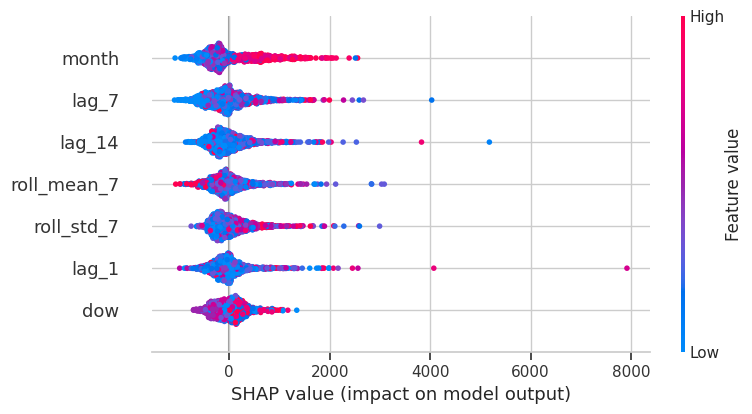

In [ ]:
# Define training cutoff for SHAP analysis
HORIZON = 7
final_train_end = ts_df.index.max() - pd.Timedelta(days=HORIZON)

# Create forecast index for final horizon
test_index = pd.date_range(
    start=final_train_end + pd.Timedelta(days=1),
    periods=HORIZON,
    freq="D"
)

# Train XGBoost model on final training window and retrieve fitted model
_, xgb_model = forecast_xgb(final_train_end, test_index, return_model=True)

# Rebuild the exact training feature matrix used by the model
train_final = ml_table.loc[:final_train_end].copy()
X_train_final = train_final.drop(columns=["y"])

# Subsample training data for faster SHAP computation
X_shap = X_train_final.sample(min(2000, len(X_train_final)), random_state=42)

# Initialize SHAP TreeExplainer for the trained model
explainer = shap.TreeExplainer(xgb_model)

# Compute SHAP values and visualise global feature importance
shap_values = explainer(X_shap)

# Global feature importance
shap.summary_plot(
    shap_values,
    X_shap,
    max_display=10,
    show=True
)

## **Key Insights from SHAP Feature Attribution**

- **Calendar effects are dominant**, with **month** emerging as the most influential feature. This directly reinforces the exploratory findings of strong monthly seasonality, characterised by late-year demand surges and early-year slowdowns.

- **Lagged demand features (lag_7 and lag_14)** play a central role, indicating that the model captures short-term momentum and recurring weekly structure through realised recent sales levels rather than relying solely on fixed categorical patterns.

- **Rolling statistics (7-day mean and volatility)** contribute materially to predictions, demonstrating that the model incorporates recent demand level and stability. This reduces sensitivity to isolated daily spikes while preserving responsiveness to sustained shifts.

- **Immediate persistence (lag_1)** shows secondary and episodic influence, suggesting that unusually high or low recent observations can temporarily affect forecasts without dominating overall behaviour.

- **Day-of-week effects** appear comparatively weak, with SHAP values clustered near zero. This implies that explicit intra-week categorical encoding provides limited additional explanatory power beyond what is already captured by lagged features.

---

### **Interpretation**

> The SHAP attribution profile indicates that forecasts are driven by adaptive temporal signals that combine strong calendar seasonality with recent demand dynamics. The model relies more heavily on structured seasonal patterns and short-term momentum than on rigid categorical labels or transient noise.  
>  
> This alignment between learned feature importance and observed demand structure supports stable short-term forecasting behaviour and reinforces confidence in the model's predictive reliability.

---

# **Conclusion and Practical Implications**

This analysis evaluated a diverse set of forecasting approaches on a highly volatile daily sales series using leakage-free rolling-origin backtesting and a fixed 7-day forecast horizon. The data exhibit pronounced calendar effects, recurring monthly structure, and irregular demand spikes, naturally producing elevated absolute error metrics across all models.

In this context, relative performance differences, robustness to extreme deviations, and stability under recursive multi-step forecasting provide a more meaningful basis for model comparison than raw error magnitudes alone.

---

## **Key Conclusions from the Modelling Analysis**

- **XGBoost delivered the strongest overall performance**, achieving the lowest MAE, RMSE, and WMAPE across rolling folds. RMSE improved by approximately **25-31% relative to naive and seasonal naive baselines**, indicating superior robustness to volatility and improved accuracy during high-impact periods.

- **Prophet and SARIMA** formed a strong second tier, confirming that explicit modelling of trend and seasonality remains highly effective when demand dynamics are driven by regular calendar structure.

- **Random Forest and ARIMA** captured meaningful temporal dependencies but underperformed relative to boosted and explicitly seasonal approaches, reflecting limitations in residual correction and seasonal representation.

- **Naive, seasonal naive, and LSTM models** underperformed, demonstrating that rigid repetition assumptions and sequence-based deep learning do not inherently outperform well-structured feature-based models in spike-driven, moderately sized datasets evaluated under recursive forecasting constraints.

- SHAP-based interpretability analysis confirms that predictive strength is driven primarily by **month-level seasonality**, **weekly lag effects**, and **recent rolling demand dynamics**, explaining both forecast stability and improved RMSE performance.

- Signed error analysis under rolling-origin evaluation reveals that all models exhibit negative Mean Forecast Error (MFE), indicating a structural tendency to under-forecast spike-driven daily demand.

- XGBoost reduces systematic under-forecast bias by approximately **46-47% relative to the naive baseline** (MFE -779 vs -1,457) and lowers the frequency of under-prediction, strengthening demand calibration under volatile conditions.

---

## **Sales Forecast Interpretation**

The final short-term forecast aligns closely with historically observed calendar-driven demand behaviour:

- Elevated demand on **31 December 2018** reflects recurring year-end purchasing and promotional activity.
- The decline on **1 January 2019** corresponds to reduced commercial activity during the New Year holiday period.
- Demand recovery from **5 January onward** mirrors established post-holiday normalisation patterns.

This coherence between exploratory analysis, model structure, and forecast behaviour reinforces confidence in the model's validity.

---

## **Actionable Recommendations**

- **Plan proactively around predictable holiday transitions:** Account for year-end surges followed by short-lived slowdowns rather than extrapolating peak demand.
- **Maintain calendar-aware forecasting frameworks:** Seasonal and month-level effects should remain central to short-term planning.
- **Avoid reactive decisions based on isolated spikes:** Operational responses should be guided by stabilised multi-day forecasts rather than single-day anomalies.
- **Time replenishment around post-holiday recovery:** Early January rebound periods present strategic opportunities for inventory alignment and targeted promotion.
- **Monitor directional forecast bias as a governance metric:** Track Mean Forecast Error alongside RMSE to detect persistent under- or over-forecast patterns and recalibrate models if structural bias begins to emerge.

---

# **Business Impact**

A **25-31% reduction in RMSE relative to baseline models**, combined with a **46-47% reduction in systematic under-forecast bias**, represents a material operational improvement. Lower overall error reduces volatility exposure, while improved directional calibration decreases persistent underestimation during high-demand periods.  

More accurate and better-calibrated short-term forecasts enable tighter inventory positioning, improved product availability, and more predictable fulfilment performance, while reducing reactive operational adjustments and associated cost volatility.

---

# **Overall Conclusion**

Feature-based gradient boosting, as implemented through XGBoost, provides the most effective balance of adaptability, robustness, and operational value for short-term daily sales forecasting under volatile demand conditions.

Classical seasonal time series models remain strong, interpretable benchmarks. However, increased model complexity, particularly in deep sequence architectures, does not inherently translate into superior forecasting performance or business benefit in this setting.

Model effectiveness ultimately depends not on theoretical sophistication, but on alignment between modelling assumptions and the structural characteristics of the demand series.

# **Future Work**

Several extensions could further enhance forecast accuracy, robustness, and operational value.

- **Targeted hyperparameter optimisation of top-performing models (XGBoost, Prophet, SARIMA):**  
  Given their strong baseline performance, systematic tuning of learning rates, tree depth, and regularisation strength (XGBoost), seasonal components and changepoints (Prophet), and seasonal orders (SARIMA) may yield incremental gains. Focused optimisation is likely to be more impactful than increasing model complexity.

- **Incorporation of explicit holiday and promotion indicators:**  
  Introducing structured event-level features could improve performance during spike-driven periods that are not fully captured by generic calendar variables, particularly around major year-end and promotional events.

- **Probabilistic forecasting and prediction intervals:**  
  Extending the framework to produce uncertainty estimates would support risk-aware decision-making. In highly volatile daily demand environments, understanding forecast dispersion is often as important as point accuracy.

- **Direct multi-step forecasting strategies:**  
  Evaluating direct horizon-specific models may reduce error accumulation inherent in recursive approaches, particularly if the forecast horizon is extended beyond seven days.

- **Hierarchical or segmented forecasting:**  
  Building region-, category-, or customer-segment-specific models, as suggested by the exploratory analysis, may capture heterogeneous demand structures that are diluted in fully aggregated forecasts.

---

Overall, future improvements should prioritise structural alignment and uncertainty quantification rather than indiscriminate increases in model complexity. Enhancing interpretability, segmentation, and probabilistic insight would further strengthen the practical deployment readiness of the forecasting system.

## **Note on Model-Specific Training Windows**

In this project, each model was trained using an optimal rolling window configuration aligned with its structural characteristics and data requirements.  

While fixed-window benchmarks are appropriate in strictly controlled academic settings, practical forecasting systems typically allow models to utilise the history length that best supports their learning dynamics. This approach more accurately reflects real-world deployment conditions, where model performance and operational reliability take precedence over rigid experimental symmetry.

The table below summarises how each model leverages historical data and whether a defined lookback window is structurally required.

| Model          | How It Uses Historical Data                                  | Need for Lookback Window                          |
|---------------|---------------------------------------------------------------|--------------------------------------------------|
| Prophet       | Decomposes the series into trend and seasonal components      | Not strictly required; can operate on full history |
| ARIMA / SARIMA| Models autoregressive and moving-average relationships        | Can use full history; explicit windowing optional |
| Random Forest | Learns from engineered lagged and rolling features            | Required; window length defines lag structure     |
| XGBoost       | Learns nonlinear interactions from lagged features            | Required; window length defines lag structure     |
| LSTM          | Models temporal dependencies through input sequences          | Required; window length defines sequence length   |

This design choice ensures that each modelling approach is evaluated under conditions that reflect its intended operational use, rather than constraining flexible models to artificially uniform historical windows.